In [1]:
from innolux import *
project_data_path = data_path / "T2 6117" / "LC Pattern"

In [11]:
raw_df = pl.read_excel(project_data_path / "LC Pattern 內衝確認_20260123.xlsx")

In [12]:
raw_df

位置,Pattern,Cut ID,膜位,內衝,膠寬
i64,str,str,str,i64,i64
3,"""F""","""HN201B""","""17""",0,699
3,"""F""","""HN201B""","""19""",0,704
3,"""F""","""HN201B""","""1B""",0,641
3,"""F""","""HN201B""","""3A""",0,625
3,"""F""","""HN201B""","""47""",57,697
…,…,…,…,…,…
11,"""D""","""HN207B""","""4C""",0,764
11,"""D""","""HN207B""","""59""",0,836
11,"""D""","""HN207B""","""78""",0,689


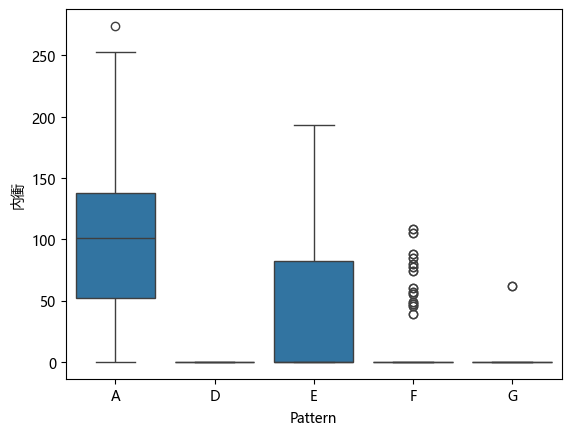

In [13]:
ax = sns.boxplot(
    raw_df.sort('Pattern'),
    x='Pattern',
    y='內衝'
)

In [20]:
(raw_df
    .select("Pattern", "Cut ID", "膜位")
    .unique()
    .group_by("Pattern")
    .len()
    .sort('Pattern')
)

Pattern,len
str,u32
"""A""",10
"""D""",20
"""E""",20
"""F""",20
"""G""",20


(500.0, 900.0)

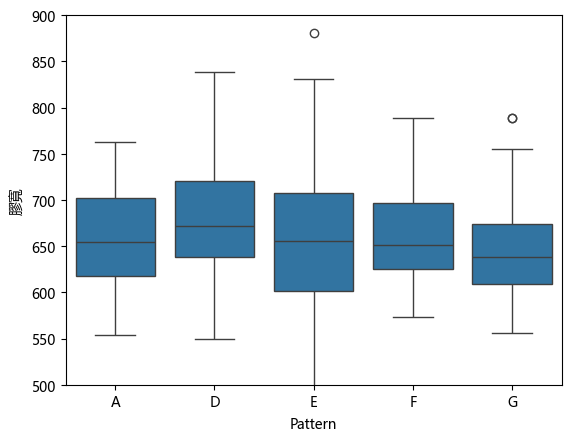

In [21]:
ax = sns.boxplot(
    raw_df.sort('Pattern'),
    x='Pattern',
    y='膠寬'
)
ax.set_ylim(500, 900)

In [23]:
t2_6628 = pl.read_excel(project_data_path / 'T2_6628_薄板_seal_width_內衝.xlsx')

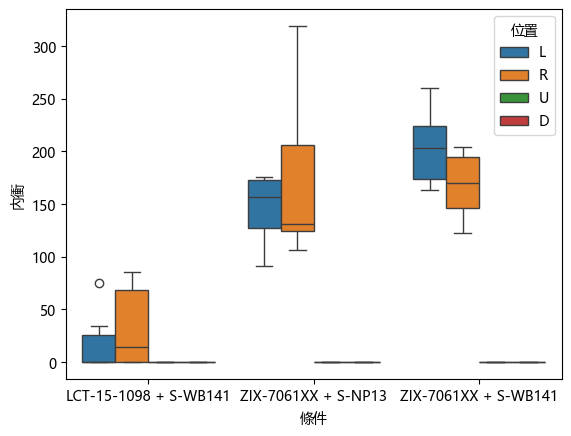

In [34]:
ax = sns.boxplot(
    t2_6628,
    x='條件',
    y='內衝',
    hue="位置",
)

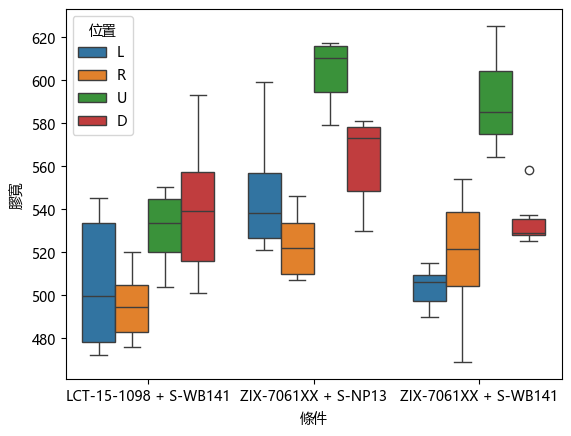

In [33]:
ax = sns.boxplot(
    t2_6628,
    x='條件',
    y='膠寬',
    hue="位置",
)
# ax.set_ylim(500, 900)

In [29]:
t2_6628.select('條件', 'ID').unique().group_by('條件').len()

條件,len
str,u32
"""LCT-15-1098 + S-WB141""",6
"""ZIX-7061XX + S-WB141""",6
"""ZIX-7061XX + S-NP13""",7


In [36]:
(
    t2_6628
    .group_by(["條件", "ID"])
    .mean()
    .filter(pl.col('內衝') > 0)
    .group_by("條件")
    .len()
)

條件,len
str,u32
"""ZIX-7061XX + S-NP13""",7
"""ZIX-7061XX + S-WB141""",6
"""LCT-15-1098 + S-WB141""",3


In [32]:
t2_6628.sort("內衝",descending=True)

條件,ID,位置,膠寬,內衝
str,str,str,i64,i64
"""ZIX-7061XX + S-NP13""","""214B85""","""R""",546,319
"""ZIX-7061XX + S-NP13""","""214B75""","""R""",510,280
"""ZIX-7061XX + S-WB141""","""215BA4""","""L""",510,260
"""ZIX-7061XX + S-WB141""","""215C96""","""L""",508,230
"""ZIX-7061XX + S-WB141""","""215B95""","""L""",504,206
…,…,…,…,…
"""ZIX-7061XX + S-WB141""","""215B95""","""D""",528,0
"""ZIX-7061XX + S-WB141""","""215BA4""","""D""",530,0
"""ZIX-7061XX + S-WB141""","""215B54""","""D""",528,0
